# Ising formulations of many NP problems
## Imports

In [8]:
import numpy as np
import scipy
import math
import random

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

from IPython.display import HTML,display

import networkx as nx

from numba import njit


## Spin glass annealing
Importing the code _spinglass.ipynb_ from 

In [9]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return 0.5 * s @ J @ s - h @ s

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


# Partitioning Problems
These partitioning problems are based off _spinglass.ipynb_  where we have a spin glass model.

$H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

 We will need to swap the general ising model build function `make_2d_ising(N,J_scalar,h_scalar)` to a function that has our problems ising structure. Building Q based off the energy cost function is our goal here.

## Number Partitioning 
Given a set of $N$ positive numbers $S=\{n_1,\cdots ,n_N\}$, is there a partition of numbers into two disjoint sets such that $R$ and $S-R$ have equal sums of their elements?

Our cost function will be,

$H=-A\left(\sum_i^Nn_is_i\right)^2=$

$\underbrace{-A\sum_{i=j}^Nn_i^2}_\text{constant}-2A\sum_{i<j}^Nn_in_js_is_j$

we can drop the constant in our optimization.

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

$J_{ij}=-An_in_j$

$h_i=0$

In [10]:
def make_partition_ising_slower(n,A=1.0):
    n = np.asarray(n, dtype=np.float64)
    N=len(n)
    J = np.zeros((N,N))
    
    for i in range(N):
        for j in range(i+1,N):
            J[i,j] = -A * n[i] * n[j]
            J[j,i] = J[i,j]
    
    h = np.zeros(N)
    
    return J, h
    
def make_partition_ising(n, A=1.0):
    n = np.asarray(n, dtype=np.float64)

    J = -2 * A * np.outer(n, n)
    np.fill_diagonal(J, 0.0)

    h = np.zeros(len(n))

    return J, h

This structure defines ouf Q interaction matrix.

In [11]:
numbers = np.array([3,1,1,2,2,1])

J, h = make_partition_ising(numbers)

temps, energies, spins = sim_annealing(
    J, h,
    T_start=10,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=100
)

setA = numbers[spins == 1]
setB = numbers[spins == -1]

print("Set A:", setA, "sum =", np.sum(setA))
print("Set B:", setB, "sum =", np.sum(setB))
print("Difference =", abs(np.sum(setA) - np.sum(setB)))

Set A: [2 2 1] sum = 5
Set B: [3 1 1] sum = 5
Difference = 0


Defining a function for this problem

In [12]:
def run_partition_example(numbers,sweeps):
    print("Inputed numbers:", numbers)

    J, h = make_partition_ising(numbers)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    setA = numbers[spins == 1]
    setB = numbers[spins == -1]

    print("Set A:", setA, "sum =", np.sum(setA))
    print("Set B:", setB, "sum =", np.sum(setB))
    print("Difference =", abs(np.sum(setA) - np.sum(setB)))

We can try it for a random $n_i=rand$ for $S=\{n_1,\cdots ,n_N\}$

In [13]:
for _ in range(5):
    random_numbers = np.random.randint(1, 100, size=20)
    print(run_partition_example(random_numbers, 1000))

Inputed numbers: [63 16 94 18 23 48 72 38 94 44 50 43 13  6 68 36 37 49 40 56]


Set A: [63 94 72 44 50  6 37 49 40] sum = 455
Set B: [16 18 23 48 38 94 43 13 68 36 56] sum = 453
Difference = 2
None
Inputed numbers: [74 41 39  6 44 93 85 59 86 48 36 50 67 44 92 15 70 14  3 95]
Set A: [74 41 39 93 59 44 70 14  3 95] sum = 532
Set B: [ 6 44 85 86 48 36 50 67 92 15] sum = 529
Difference = 3
None
Inputed numbers: [61 44 33 68 72 98 49 29 44 94 20 15 31 21 73 94 20 27 46 89]
Set A: [44 68 29 20 31 21 73 94 46 89] sum = 515
Set B: [61 33 72 98 49 44 94 15 20 27] sum = 513
Difference = 2
None
Inputed numbers: [42 51  8 71 42  9 16 53 97 57 30 30  6 60 37 58 56 38 60 96]
Set A: [42 71 42 53 57 30  6 60 58 38] sum = 457
Set B: [51  8  9 16 97 30 37 56 60 96] sum = 460
Difference = 3
None
Inputed numbers: [30 15 20 51 73 94 71 19 10 94 52 27 45 24 36 27 85 87 58 26]
Set A: [15 20 71 19 94 27 45 36 85 58] sum = 470
Set B: [30 51 73 94 10 52 24 27 87 26] sum = 474
Difference = 4
None


It solves our problem to the best of its ability, minimising the distance between two sets.

## Graph Partitioning

Given some undirected graph $G(V,E)$, where $v\in v$ are vertices and $e\in E$ are edges, we take a graph with and even number of edges $N=|V|$. The optimisation problem, what is the partition of V into two subsets that minimises the number of edges connecting the two subsets?

$ H=H_A+H_B$

$=A\left(\sum_i^Ns_i\right)^2+B\sum_{(i,j)\in E}\frac{1-s_is_j}{2}$

$=\underbrace{AN} _{\text{constant}}+\underbrace{\frac{B|E|}{2}}_{\text{constant}}+2A\sum_{i>j}^ Ns_is_j -\frac{B}{2}\sum_{(i,j)\in E}  s_is_j$

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$. 

$J_{ij}=\begin{cases}
        -2A ~~~~~~~~~\text{if }~(i,j)\notin E\\
        -2A -\frac{B}{2}~~~\text{if }~(i,j)\in E
    \end{cases}$

$h_i=0$

In [14]:
nodes = ['a', 'b', 'c', 'd']
#     idx 0    1    2    3
idx = {v: i for i, v in enumerate(nodes)}

print(nodes)
print(idx)

# idx swaps label and index of nodes in a graph

['a', 'b', 'c', 'd']
{'a': 0, 'b': 1, 'c': 2, 'd': 3}


In [15]:
def make_graph_partition(G, A, B):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    
    J = -2.0 * A * np.ones((N, N))
    np.fill_diagonal(J, 0.0)
    
    #
    idx = {v:i for i,v in enumerate(nodes)}
    
    for u,v in G.edges():
        i, j = idx[u], idx[v]
        J[i,j] += B/2.0
        J[j,i] += B/2.0
    
    h = np.zeros(N)
    return J, h

def decode_partition_solution(G, s):
    nodes = list(G.nodes())
    
    setA = [nodes[i] for i in range(len(s)) if s[i] == 1]
    setB = [nodes[i] for i in range(len(s)) if s[i] == -1]
    
    cut_edges = [(u,v) for u,v in G.edges() if (u in setA) != (v in setA)]
    
    print ("Set A:", setA , "size =", len(setA))
    print ("Set B:", setB , "size =", len(setB))
    print ("Cut edges:", cut_edges , "size =", len(cut_edges))
    
    return setA, setB, cut_edges

def check_valid_AB(A,B,G):
    N=G.number_of_nodes()
    delta=max(d for _,d in G.degree()) # max degree of graph
    rhs=min(2*delta, N)/8 
    lhs= A / B
    valid = lhs >= rhs
    print(f"Max degree Δ={delta},  bound A/|B| >= {rhs:.3f}")
    print(f"Current A/|B| = {lhs:.3f}  {'valid' if valid else 'INVALID'}")
    
    return valid

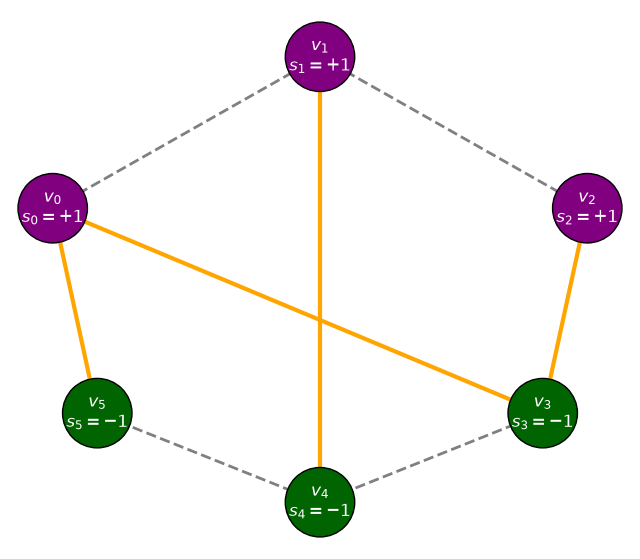

In [16]:
# Cycle graph C6 plus two connections
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

# positions for nodes in the graph for plotting to match my layout in Tikz
pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}

# worst spin configuration
spins = np.array([1, 1, 1, -1, -1, -1])

# Colour nodes
node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

# Separate cut and internal edges
cut_edges = []
internal_edges = []

for u, v in G.edges():
    if spins[u] != spins[v]:
        cut_edges.append((u, v))
    else:
        internal_edges.append((u, v))

plt.figure(figsize=(8,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors='black'
)

# Labels
labels = {i: f"$v_{i}$\n$s_{{{i}}}={spins[i]:+d}$" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_color='white')

# Internal edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=internal_edges,
    edge_color='gray',
    style='dashed',
    width=2
)

# Cut edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=cut_edges,
    edge_color='orange',
    width=3
)

plt.axis('off')
plt.axis('equal')
plt.show()

We can make a plotting function without defining postions using `pos = nx.spring_layout(G, seed=13)` with a seed for reproducibility. Instead of inputing

`pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}`

We'll also make a spin-less/empty node graph function

In [17]:
def draw_empty_graph(G):
    pos = nx.spring_layout(G, seed=13)  

    n = G.number_of_nodes()
    
    node_colors = 'purple'

    all_edges = []

    for u, v in G.edges():
        all_edges.append((u, v))

    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {i: f"$v_{i}$" for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=all_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

And one with the cut edges defined once we input a spin.

In [18]:
def draw_graph_partition(G, spins):
    pos = nx.spring_layout(G, seed=13)  
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    n = G.number_of_nodes()
    
    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {}

    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    # Cut edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges,
        edge_color='orange',
        width=3
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

In [19]:
def run_partition_graph_example(G, A, B, sweeps):
    print("Inputed graph:")
    draw_empty_graph(G)
    
    print(f"A={A}, B={B}")
    check_valid_AB(A, B, G)

    J, h = make_graph_partition(G, A, B)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    #setA, setB, cut_edges = decode_partition_solution(G, spins)
    
    draw_graph_partition(G, spins)

Inputed graph:


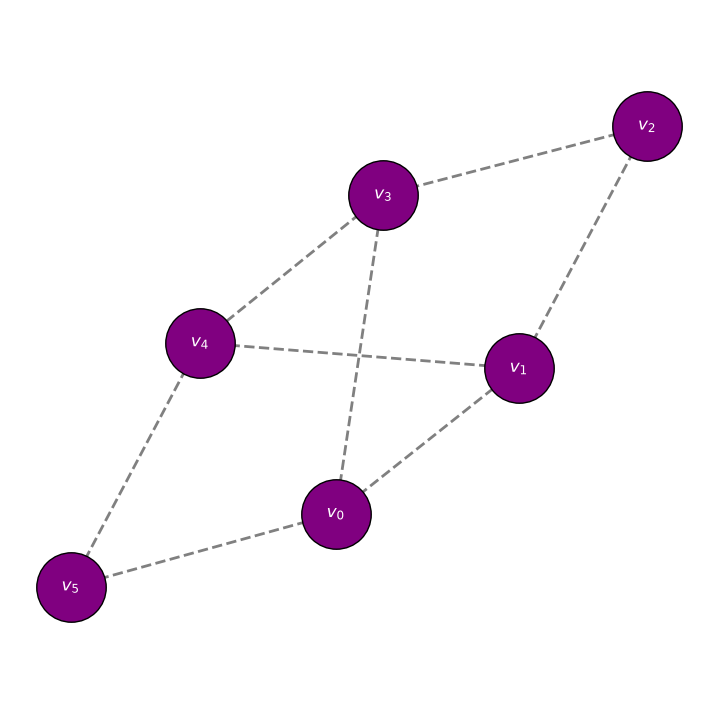

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


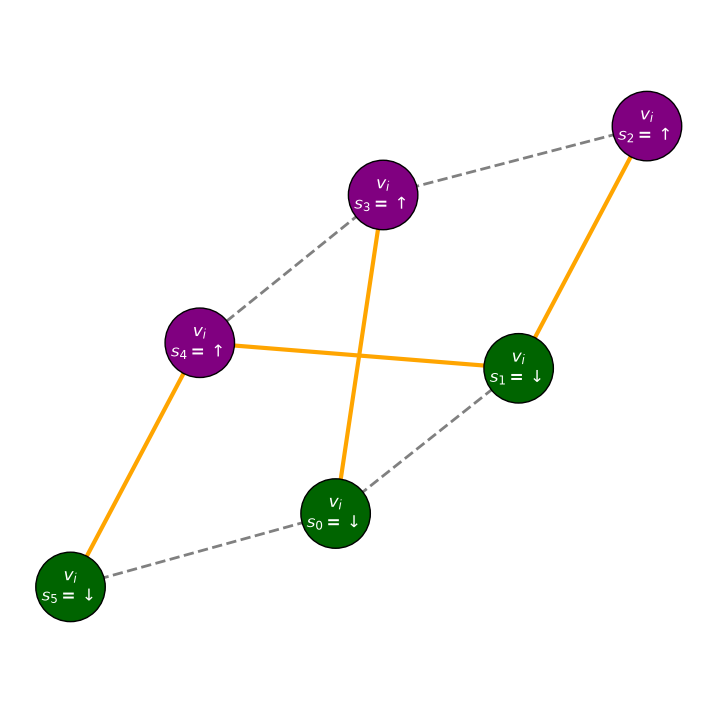

In [20]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

run_partition_graph_example(G, A=4, B=2, sweeps=1000)

That is solving the problem to minimise the cut edes, now we can try it with random $G(E,V)$

In [21]:
def run_random_partition_graph_example(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    run_partition_graph_example(G, A=4, B=2, sweeps=1000)

n = 8
Added 4 extra edges
Inputed graph:


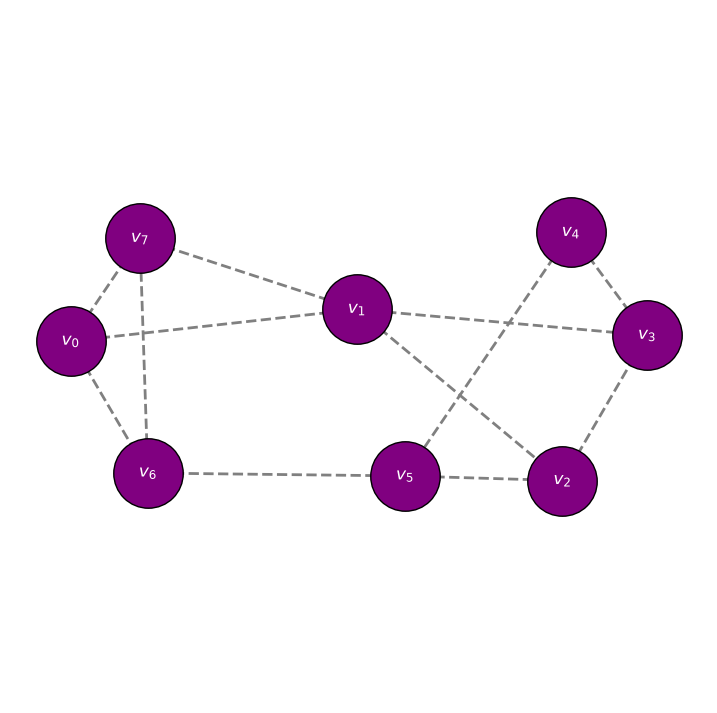

A=4, B=2
Max degree Δ=4,  bound A/|B| >= 1.000
Current A/|B| = 2.000  valid


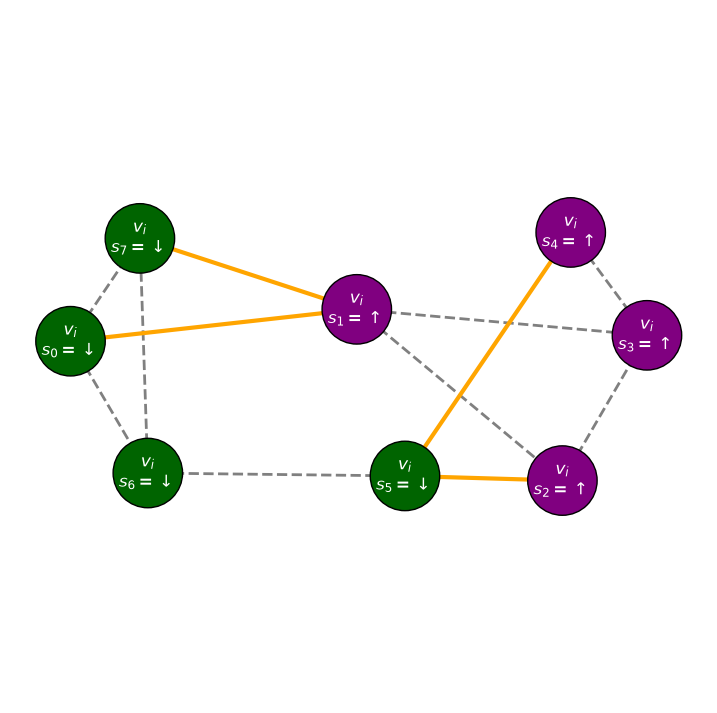

In [22]:
run_random_partition_graph_example(6, 20)

#### Animation

I think it'd be fun to plot the annealing process. We need to save the spin history in the annealing, then update our spins diagrams.

Redefining the annealing,



In [23]:
def sim_annealing_animation(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    history = []
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        history.append(s.copy())
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy(), history

In [ ]:
def update(frame):
    
    ax.clear()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    
    spins = history[frame]
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1900,
        edgecolors='black',
        ax=ax
    )
    
    # Labels
    labels = {}
    
    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_color="white",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=internal_edges,
        edge_color="gray",
        style="dashed",
        width=2,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        edge_color="orange",
        width=3,
        ax=ax,
    )
    
    ax.set_title(
        f"Step {frame} | "
        f"T = {temps[frame]:.3f} | "
        f"E = {energies[frame]:.2f}",
        fontsize=16
    )
    
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    

In [32]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

def run_partition_graph_animation(G):
    pos = nx.spring_layout(G, seed=13)

    # fix the axis limits to avoid rescaling during the animation
    x_values = [p[0] for p in pos.values()]
    y_values = [p[1] for p in pos.values()]

    margin = 0.5

    xlim = (min(x_values)-margin, max(x_values)+margin)
    ylim = (min(y_values)-margin, max(y_values)+margin)

    n = G.number_of_nodes()
    size = max(9, 0.8 * n)

    fig, ax = plt.subplots(figsize=(size, size))

    J, h = make_graph_partition(G, A=4, B=4)
    temps, energies, spins, history = sim_annealing_animation(
        J,
        h,
        T_start=10,
        T_end=0.05,
        alpha=0.99,
        sweeps_per_T=1000
        )

    history = history[::2]  # downsample the history for faster animation
    energies = energies[::2]  # downsample the energies for faster animation
    temps = temps[::2]  # downsample the temperatures for faster animation
    spins = spins[::2]  # downsample the spins for faster animation

    def update(frame):
        
        ax.clear()
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        
        spins = history[frame]
        
        # Colour nodes
        node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

        # Separate cut and internal edges
        cut_edges = []
        internal_edges = []

        for u, v in G.edges():
            if spins[u] != spins[v]:
                cut_edges.append((u, v))
            else:
                internal_edges.append((u, v))

        # Nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_colors,
            node_size=1900,
            edgecolors='black',
            ax=ax
        )
        
        # Labels
        labels = {}
        
        for i in G.nodes:
            arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
            labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
        
        nx.draw_networkx_labels(
            G,
            pos,
            labels,
            font_color="white",
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=internal_edges,
            edge_color="gray",
            style="dashed",
            width=2,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=cut_edges,
            edge_color="orange",
            width=3,
            ax=ax,
        )
        
        ax.set_title(
            f"Step {frame} | "
            f"T = {temps[frame]:.3f} | "
            f"E = {energies[frame]:.2f}",
            fontsize=16
        )
        
        ax.set_axis_off()
        ax.set_aspect("equal")
    
    
    
    animation = FuncAnimation(fig, update, frames=len(history), interval=500, repeat=False)
    
    return animation

In [35]:
# display the animation in the notebook
# display(HTML(animation.to_jshtml()))

# download the animation as a GIF
'''
animation.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)
'''

'\nanimation.save(\n    "annealing.gif",\n    writer=PillowWriter(fps=10)\n)\n'

In [33]:
def run_random_partition_graph_animation(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    anim_random = run_partition_graph_animation(G)
    
    return anim_random

n = 10
Added 2 extra edges


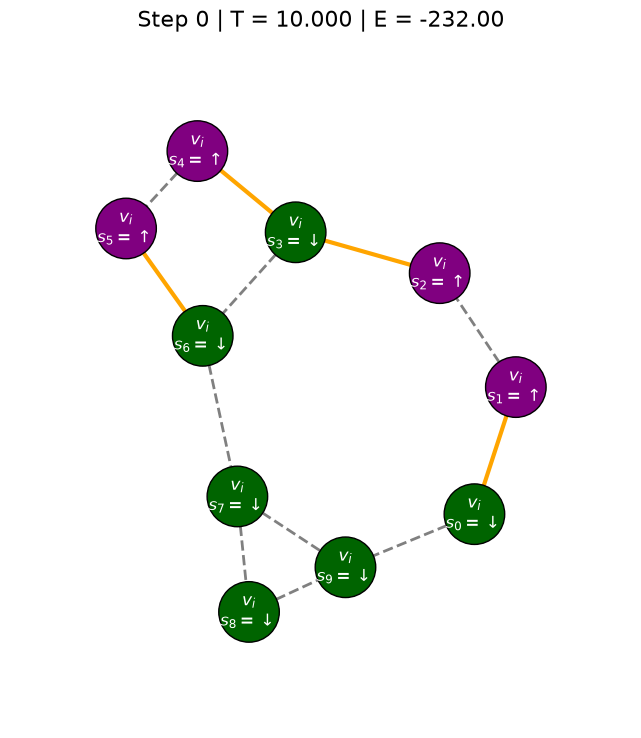

In [34]:
anim = run_random_partition_graph_animation(6, 30)
anim.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)

These seem to work, they're a nice display of the annealing process.

## Binary Lineary Integer Programing

